# Lista 5

## Pandas i Dask

(8pkt + 2pkt)

Na liście znajduje się 8 zadań. Po rozwiązaniu zadania pokaż kod prowadzącemu i odpowiedz na **pytanie kontrolne** — tylko wtedy przyznajemy punkty. Dodatkowo prześlij zadanie na platformie skos.

Zadanie dodatkowe oznaczone jest ⭐️. Za wykonanie zadania otrzymasz 2pkt.

### Pandas

Rozważ bazę danych z wykładu i rozwiąż poniższe zadania.

In [42]:
import numpy as np
import pandas as pd

N = 100000

data_ = np.random.randint(1000, size=(N, 4))

df = pd.DataFrame(data_, columns=['time', 'uid', 'pid', 'rating'])
df['time'] = np.random.randint(24 * 60 * 60, size=(N))
df['time'] = pd.to_datetime('2025-01-01') + pd.to_timedelta(1e9 * df['time'])
df['rating'] = np.random.randint(10, size=(N))

df.head()

,time,uid,pid,rating
0,2025-01-01 03:38:51,923,820,3
1,2025-01-01 22:03:02,144,247,5
2,2025-01-01 03:26:37,809,379,6
3,2025-01-01 18:13:40,288,158,1
4,2025-01-01 10:48:06,776,635,9


#### Zadanie 1

Dla każdego użytkownika znajdź produkt (`pid`), który ocenił najczęściej.

In [43]:
d1 = df.groupby(['uid', 'pid']).size().reset_index(name="count")
result = d1.loc[d1.groupby('uid')['count'].idxmax()]
result[['uid', 'pid', 'count']].set_index('uid')


,pid,count
uid,,
0,294,2
1,400,2
2,15,2
3,172,2
4,837,2
...,...,...
995,80,2
996,282,3
997,402,2


#### Zadanie 2

Policz liczbę ocen w każdej godzinie dnia.

**Wskazówka**

Użyj `resample()`.

In [44]:
df.set_index('time').resample('1h').count()['rating']

time
2025-01-01 00:00:00    4079
2025-01-01 01:00:00    4194
2025-01-01 02:00:00    4206
2025-01-01 03:00:00    4080
2025-01-01 04:00:00    4147
2025-01-01 05:00:00    4114
2025-01-01 06:00:00    4237
2025-01-01 07:00:00    4131
2025-01-01 08:00:00    4236
2025-01-01 09:00:00    4316
2025-01-01 10:00:00    4109
2025-01-01 11:00:00    4164
2025-01-01 12:00:00    4199
2025-01-01 13:00:00    4037
2025-01-01 14:00:00    4157
2025-01-01 15:00:00    4239
2025-01-01 16:00:00    4257
2025-01-01 17:00:00    4132
2025-01-01 18:00:00    4257
2025-01-01 19:00:00    4137
2025-01-01 20:00:00    4216
2025-01-01 21:00:00    4164
2025-01-01 22:00:00    4089
2025-01-01 23:00:00    4103
Freq: h, Name: rating, dtype: int64

#### Zadanie 3

Wybierz oceny użytkowników w godzinach pracy: od 8:00 do 16:00. Następnie dla każdego produktu (`pid`) policz: liczbę ocen, średnią i maksymalną ocenę.

In [45]:
df.set_index('time').between_time('8:00', '16:00').groupby('pid').agg(['count', 'max', 'mean'])['rating']


,count,max,mean
pid,,,
0,32,9,4.593750
1,35,9,3.914286
2,37,9,3.621622
3,48,9,4.020833
4,39,9,4.743590
...,...,...,...
995,35,9,4.800000
996,26,9,4.576923
997,34,9,4.500000


#### Zadanie 4

Przekształć kolumnę `rating` na słowa:

* 0–3 → "niska"
* 4–6 → "średnia"
* 7–9 → "wysoka"

**Wskazówka**

Użyj `map()`.

In [46]:
def rating_label(x):
    if int(x) <= 3:
        return 'niska'
    elif int(x) <= 6:
        return 'średnia'
    else:
        return 'wysoka'
d4 = df.copy()
d4['rating'] = d4['rating'].map(rating_label)
d4

,time,uid,pid,rating
0,2025-01-01 03:38:51,923,820,niska
1,2025-01-01 22:03:02,144,247,średnia
2,2025-01-01 03:26:37,809,379,średnia
3,2025-01-01 18:13:40,288,158,niska
4,2025-01-01 10:48:06,776,635,wysoka
...,...,...,...,...
99995,2025-01-01 15:30:13,363,689,średnia
99996,2025-01-01 11:31:21,523,651,wysoka
99997,2025-01-01 17:05:14,15,95,wysoka
99998,2025-01-01 12:24:09,88,854,wysoka


#### Zadanie 5

Połącz tabelę *products* zawierającą nazwy produktów (`pid` → `product_name`) z głównym df.

In [47]:
products = pd.DataFrame({
    'pid': df['pid'].unique(),
    'product_name': ['Produkt_' + str(i) for i in range(len(df['pid'].unique()))]
})
d5 = df.join(products['product_name'], how='left', on='pid')

d5

,time,uid,pid,rating,product_name
0,2025-01-01 03:38:51,923,820,3,Produkt_820
1,2025-01-01 22:03:02,144,247,5,Produkt_247
2,2025-01-01 03:26:37,809,379,6,Produkt_379
3,2025-01-01 18:13:40,288,158,1,Produkt_158
4,2025-01-01 10:48:06,776,635,9,Produkt_635
...,...,...,...,...,...
99995,2025-01-01 15:30:13,363,689,4,Produkt_689
99996,2025-01-01 11:31:21,523,651,8,Produkt_651
99997,2025-01-01 17:05:14,15,95,8,Produkt_95
99998,2025-01-01 12:24:09,88,854,8,Produkt_854


#### Zadanie 6

Policz, które produkty były najczęściej oceniane w poszczególnych godzinach. Zwizualizuj to na wykresie.

/var/folders/pt/120626514sj_lgs4_d10nxjm0000gn/T/ipykernel_30239/3482111469.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(5, 'count'))


<Axes: title={'center': 'Top 5 w danych godzinach'}, xlabel='Godzina', ylabel='Liczba ocen'>

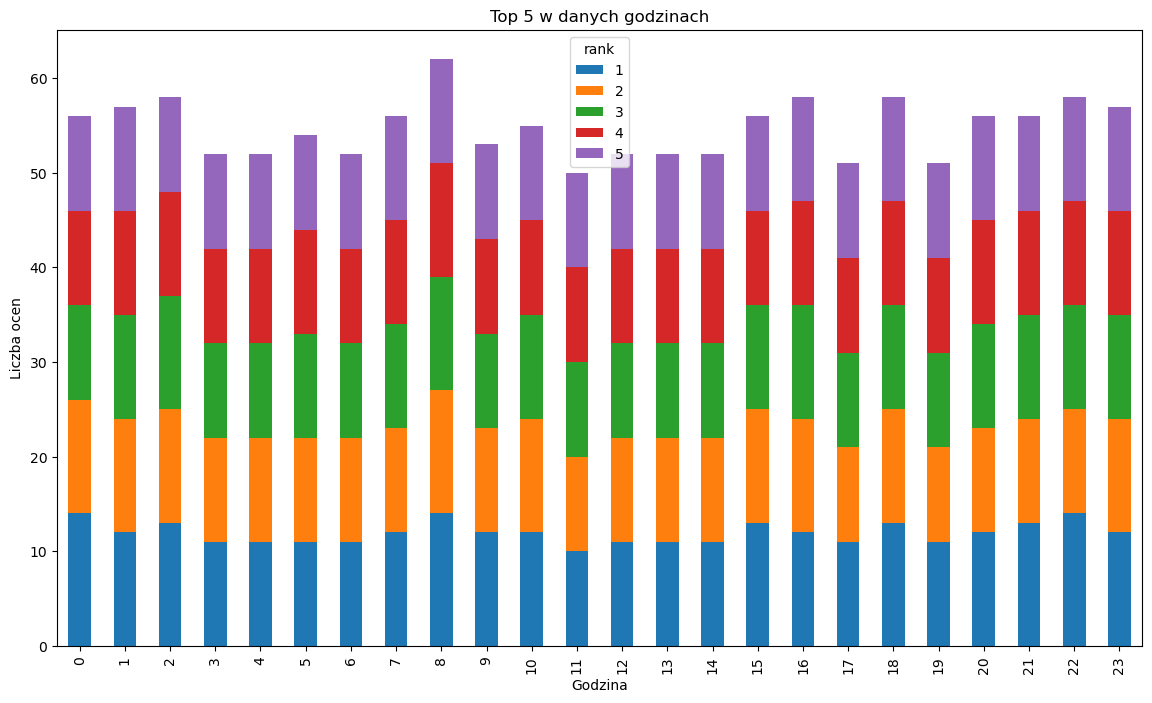

In [48]:
df['hour'] = df['time'].dt.hour
hourly_ratings = df.groupby(['hour', 'pid']).size().reset_index(name='count')

top5_per_hour = (hourly_ratings.groupby('hour')
                 .apply(lambda x: x.nlargest(5, 'count'))
                 .reset_index(drop=True))

top5_per_hour['rank'] = top5_per_hour.groupby('hour').cumcount() + 1
pivot_table = top5_per_hour.pivot_table(
    index='hour', 
    columns='rank', 
    values='count', 
    fill_value=0
)
pivot_table.plot.bar(
    stacked=True,
    figsize=(14, 8),
    title='Top 5 w danych godzinach',
    xlabel='Godzina',
    ylabel='Liczba ocen'
)

#### Zadanie 7

Utwórz dla każdego użytkownika sekwencję identyfikatorów produktów (`pid`), które ocenił, ale tylko produkty ocenione więcej niż 50 razy w godzinach od 8:00 do 16:00.

**Wskazówka**

Godzinę możesz wyodrębnić za pomocą:

```python
df['time'].dt.hour
```

In [49]:
daytime_ratings = df[(df['hour'] >= 8) & (df['hour'] <= 16)]
popular_products = daytime_ratings['pid'].value_counts()
popular_pids = popular_products[popular_products > 50].index
print(popular_pids)
filtered_ratings = daytime_ratings[daytime_ratings['pid'].isin(popular_pids)]
user_sequences = filtered_ratings.groupby('uid')['pid'].apply(list)
user_sequences


Index([376, 236, 728, 128, 155, 855, 165, 446, 69, 738, 513, 635, 935, 424,
       896, 714],
      dtype='int64', name='pid')


uid
0      [446, 376, 446]
1           [424, 424]
2                [935]
5                [513]
10               [165]
            ...       
993    [236, 128, 935]
994              [376]
996              [236]
997              [155]
998         [728, 424]
Name: pid, Length: 582, dtype: object

#### Zadanie 8

Podziel produkty na 3 grupy według „stabilności ocen” (liczba ocen produktu) i policz średnią ocenę dla każdego użytkownika w kolejnych godzinach dnia, ale tylko dla produktów należących do 3. grupy (produkty z największą liczbą ocen).

**Wskazówka**

Może się przydać funkcja `qcut()`, `merge()`.

In [50]:
product_rating_counts = df['pid'].value_counts()
product_groups = pd.qcut(product_rating_counts, 3, labels=['group1', 'group2', 'group3'])
group3_products = product_groups[product_groups == 'group3'].index

group3_data = df[df['pid'].isin(group3_products)]
group3_data['hour'] = group3_data['time'].dt.hour
hourly_ratings = group3_data.groupby(['uid', 'hour'])['rating'].mean().reset_index()
result = hourly_ratings.pivot_table(index='uid', columns='hour', values='rating', fill_value=0)
result

/var/folders/pt/120626514sj_lgs4_d10nxjm0000gn/T/ipykernel_30239/231702715.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group3_data['hour'] = group3_data['time'].dt.hour


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
uid,,,,,,,,,,,,,,,,,,,,,
0,8.000000,0.0,9.000000,2.000000,2.333333,3.500000,0.5,0.000000,7.0,7.00,...,4.750000,3.00,2.00,0.000000,3.000000,0.00,3.666667,8.5,3.5,6.000000
1,4.333333,6.0,0.000000,7.000000,0.000000,0.000000,3.0,5.000000,0.0,6.00,...,4.000000,9.00,9.00,1.000000,0.000000,3.25,4.000000,5.0,7.5,9.000000
2,4.000000,0.0,4.000000,5.000000,7.500000,0.000000,7.0,7.333333,1.0,5.00,...,0.000000,1.00,4.25,3.500000,3.000000,5.00,0.000000,5.0,6.5,5.000000
3,2.000000,4.0,2.333333,5.000000,1.333333,0.000000,2.0,5.200000,7.5,4.00,...,9.000000,0.00,5.00,5.666667,3.250000,4.20,0.000000,0.0,3.0,3.666667
4,6.000000,3.0,8.500000,1.000000,3.333333,4.000000,8.0,0.000000,3.0,0.00,...,6.333333,0.00,4.00,4.000000,3.000000,8.00,3.333333,3.0,4.0,3.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2.000000,6.0,6.000000,4.000000,5.000000,2.000000,7.0,5.750000,7.0,6.00,...,1.666667,7.00,1.00,6.000000,4.666667,4.00,4.000000,0.0,3.8,2.500000
996,2.000000,4.5,3.000000,1.500000,8.333333,6.333333,0.0,0.000000,0.0,6.25,...,5.000000,0.00,1.50,4.500000,3.000000,0.00,1.000000,5.0,7.0,0.000000
997,3.000000,3.0,0.000000,8.000000,4.000000,6.666667,3.5,0.000000,5.0,1.00,...,6.000000,2.75,2.00,6.500000,8.000000,5.25,0.000000,0.0,4.0,0.000000


### ⭐️ Dask

Wygenerujemy dane syntetyczne w Pandas i zapiszemy je do CSV.

In [51]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 1_000_000

df = pd.DataFrame({
    "uid": np.random.randint(1, 100_000, size=n),
    "movie_id": np.random.randint(1, 5000, size=n),
    "rating": np.random.uniform(1, 5, size=n).round(2),
    "timestamp": pd.date_range("2020-01-01", periods=n, freq="min")
})

df.to_csv("ratings.csv", index=False)
print("Zapisano plik: ratings.csv")

Zapisano plik: ratings.csv


#### Zadanie 1 

Wczytaj dane z pliku *ratings.csv* do Dask DataFrame. Ile partycji ma wczytany plik? Sprawdź rozmiar danych (`memory_usage()`)

In [2]:
import dask.dataframe as dd

data = dd.read_csv('ratings.csv')

print(data.memory_usage())

Dask Series Structure:
npartitions=1
    int64
      ...
Dask Name: memoryusageframe, 3 expressions
Expr=ArrowStringConversion(frame=FromMapProjectable(24249b5)).memoryusageframe()


#### Zadanie 2

Oblicz średnią ocenę oraz policz liczbę ocen > 4.

In [10]:
mean_rating = data['rating'].mean().compute()
print(mean_rating)
good_ratings = (data['rating'] > 4).sum().compute()
print(good_ratings)

2.9993551
248540


#### Zadanie 3

Pokaż, jak Dask rozkłada obliczenia na taski dla operacji:

```python
ddf.groupby("uid")["rating"].mean()
```

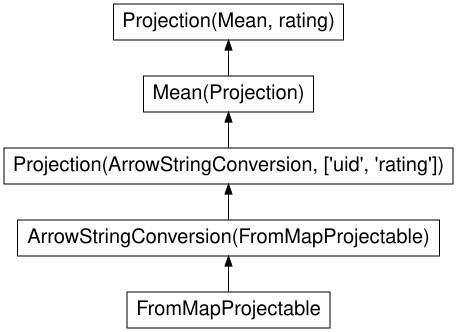

In [13]:
r = data.groupby("uid")["rating"].mean()
r.visualize(filename="dask_graph.png")


#### Zadanie 4

Znajdź 10 filmów z najwyższą średnią oceną (tylko jeśli mają >100 ocen). Niech wynik będzie zapisany w pamięci.

In [23]:
movies = data.groupby("movie_id").agg({'rating' : ['mean', 'count']}).compute()
movies = movies[movies[('rating', 'count')] > 100]
movies = movies.nlargest(10, ('rating', 'mean'))
print(movies)

            rating      
              mean count
movie_id                
621       3.353220   205
4224      3.331755   188
3736      3.293943   175
1048      3.293280   186
1500      3.284029   206
1417      3.274503   191
1626      3.273962   212
1735      3.272353   204
1227      3.271968   188
149       3.263518   199
